In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib xgboost scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 305.1/305.1 MB 1.2 MB/s eta 0:00:00


In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
from google.colab import files

print("Please select your CSV dataset file to upload...")
uploaded = files.upload()

# Grab the filename that was uploaded
file_name = list(uploaded.keys())[0]
print(f"\nUploaded file: {file_name}")

df = pd.read_csv(file_name)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Please select your CSV dataset file to upload...


Saving dataset_B_soil_climate.csv to dataset_B_soil_climate.csv

Uploaded file: dataset_B_soil_climate.csv
Dataset loaded: 215062 rows, 20 columns


,crop,latitude,longitude,region_area,awc,bulk_density,drainage_class,tavg_mean,tavg_std,tmin_min,tmax_max,prec_sum,prec_max,prec_std,rad_mean,rad_std,et0_mean,vpd_mean,cwb_sum,yield
0,maize,-9.17162,13.84699,36845.0,12.269,1.43,5.0,25.855022,1.220939,16.970,34.455,568.878,23.828,3.814411,1.850363e+07,2.342600e+06,4.245330,23.309098,-382.076,0.60
1,maize,-9.17162,13.84699,36845.0,12.269,1.43,5.0,25.782237,1.641759,16.809,37.121,383.899,19.263,2.870466,1.856202e+07,2.673137e+06,4.353973,25.537897,-591.391,0.75
2,maize,-9.17162,13.84699,36845.0,12.269,1.43,5.0,25.187778,1.868738,15.366,34.578,826.180,45.125,5.739546,1.734192e+07,2.388987e+06,3.914284,19.711889,-54.534,0.50
3,maize,-9.17162,13.84699,36845.0,12.269,1.43,5.0,25.714357,1.181715,16.698,35.063,439.640,21.066,3.425979,1.875198e+07,3.060420e+06,4.335348,24.438375,-531.478,0.34
4,maize,-9.17162,13.84699,36845.0,12.269,1.43,5.0,25.468482,1.471494,16.297,34.541,839.661,60.805,6.136435,1.829675e+07,2.491695e+06,4.102795,20.759768,-79.365,0.30


In [4]:
print("Available columns in dataset:")
for col in df.columns:
    print(f"  - {col!r}")

Available columns in dataset:
  - 'crop'
  - 'latitude'
  - 'longitude'
  - 'region_area'
  - 'awc'
  - 'bulk_density'
  - 'drainage_class'
  - 'tavg_mean'
  - 'tavg_std'
  - 'tmin_min'
  - 'tmax_max'
  - 'prec_sum'
  - 'prec_max'
  - 'prec_std'
  - 'rad_mean'
  - 'rad_std'
  - 'et0_mean'
  - 'vpd_mean'
  - 'cwb_sum'
  - 'yield'


In [5]:
TARGET_COLUMN = "yield"

assert TARGET_COLUMN in df.columns, f"'{TARGET_COLUMN}' not found in dataset columns. Please check spelling/case and update TARGET_COLUMN above."
print(f"Target column set to: '{TARGET_COLUMN}'")

Target column set to: 'yield'


In [6]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (215062, 20)

Data types:
 crop               object
latitude          float64
longitude         float64
region_area       float64
awc               float64
bulk_density      float64
drainage_class    float64
tavg_mean         float64
tavg_std          float64
tmin_min          float64
tmax_max          float64
prec_sum          float64
prec_max          float64
prec_std          float64
rad_mean          float64
rad_std           float64
et0_mean          float64
vpd_mean          float64
cwb_sum           float64
yield             float64
dtype: object

Missing values per column:
 crop              0
latitude          0
longitude         0
region_area       0
awc               0
bulk_density      0
drainage_class    0
tavg_mean         0
tavg_std          0
tmin_min          0
tmax_max          0
prec_sum          0
prec_max          0
prec_std          0
rad_mean          0
rad_std           0
et0_mean          0
vpd_mean          0
cwb_sum           0
yield             0
dty

In [7]:
df.describe(include='all')

,crop,latitude,longitude,region_area,awc,bulk_density,drainage_class,tavg_mean,tavg_std,tmin_min,tmax_max,prec_sum,prec_max,prec_std,rad_mean,rad_std,et0_mean,vpd_mean,cwb_sum,yield
count,215062,215062.000000,215062.000000,215062.000000,215062.000000,215062.000000,215062.000000,215062.000000,215062.000000,215062.000000,215062.000000,215062.000000,215062.000000,215062.000000,2.150620e+05,2.150620e+05,215062.000000,215062.000000,215062.000000,215062.000000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,maize,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,153436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3.663037,-46.624943,2694.931076,12.388308,1.415491,4.765356,20.186495,4.153212,4.683493,33.988054,634.229937,46.816100,6.639017,1.799261e+07,5.476306e+06,3.867022,16.972250,-107.934763,4.319374
std,NaN,29.636808,44.154306,7729.924939,2.158997,0.100803,0.715083,4.197156,2.354377,9.676068,3.056627,307.848998,24.126616,2.712779,2.003774e+06,1.467505e+06,0.745796,5.266280,365.241382,3.052430
min,NaN,-40.214240,-124.230640,20.000000,5.754000,0.556000,1.000000,0.964848,0.408074,-36.499000,13.445000,0.000000,0.000000,0.000000,1.023766e+07,1.279585e+06,1.808279,4.334952,-1482.601000,0.000000
25%,NaN,-22.898820,-77.915720,382.000000,10.909000,1.336000,5.000000,17.324765,2.423333,-0.634000,32.008000,430.618750,30.814250,4.934087,1.667191e+07,4.400890e+06,3.351650,13.301953,-346.369000,2.000000
50%,NaN,-9.155650,-51.284560,1201.000000,12.318000,1.422000,5.000000,20.410178,3.888152,4.469500,33.802000,605.381000,42.371000,6.479537,1.796958e+07,5.637631e+06,3.806610,16.114213,-118.186000,3.600000
75%,NaN,37.288110,-42.122440,2524.000000,14.002000,1.497000,5.000000,23.383675,5.196565,11.218000,35.689000,808.962750,57.910000,8.095365,1.932816e+07,6.674045e+06,4.303131,19.610150,107.899250,6.000000


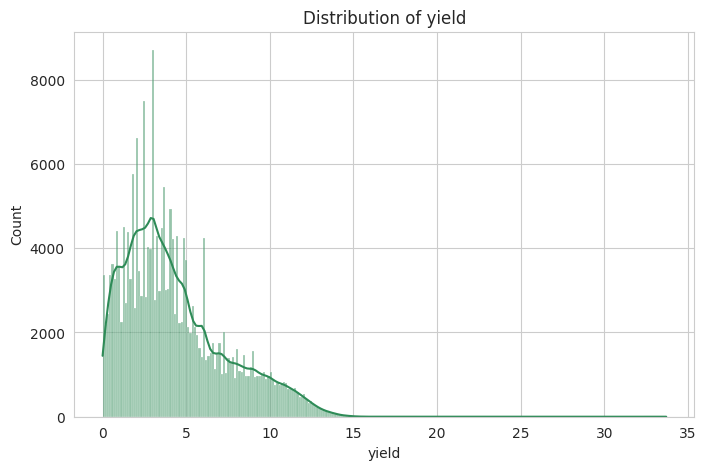

In [8]:
# Distribution of the target variable
plt.figure(figsize=(8,5))
sns.histplot(df[TARGET_COLUMN], kde=True, color='seagreen')
plt.title(f'Distribution of {TARGET_COLUMN}')
plt.xlabel(TARGET_COLUMN)
plt.show()

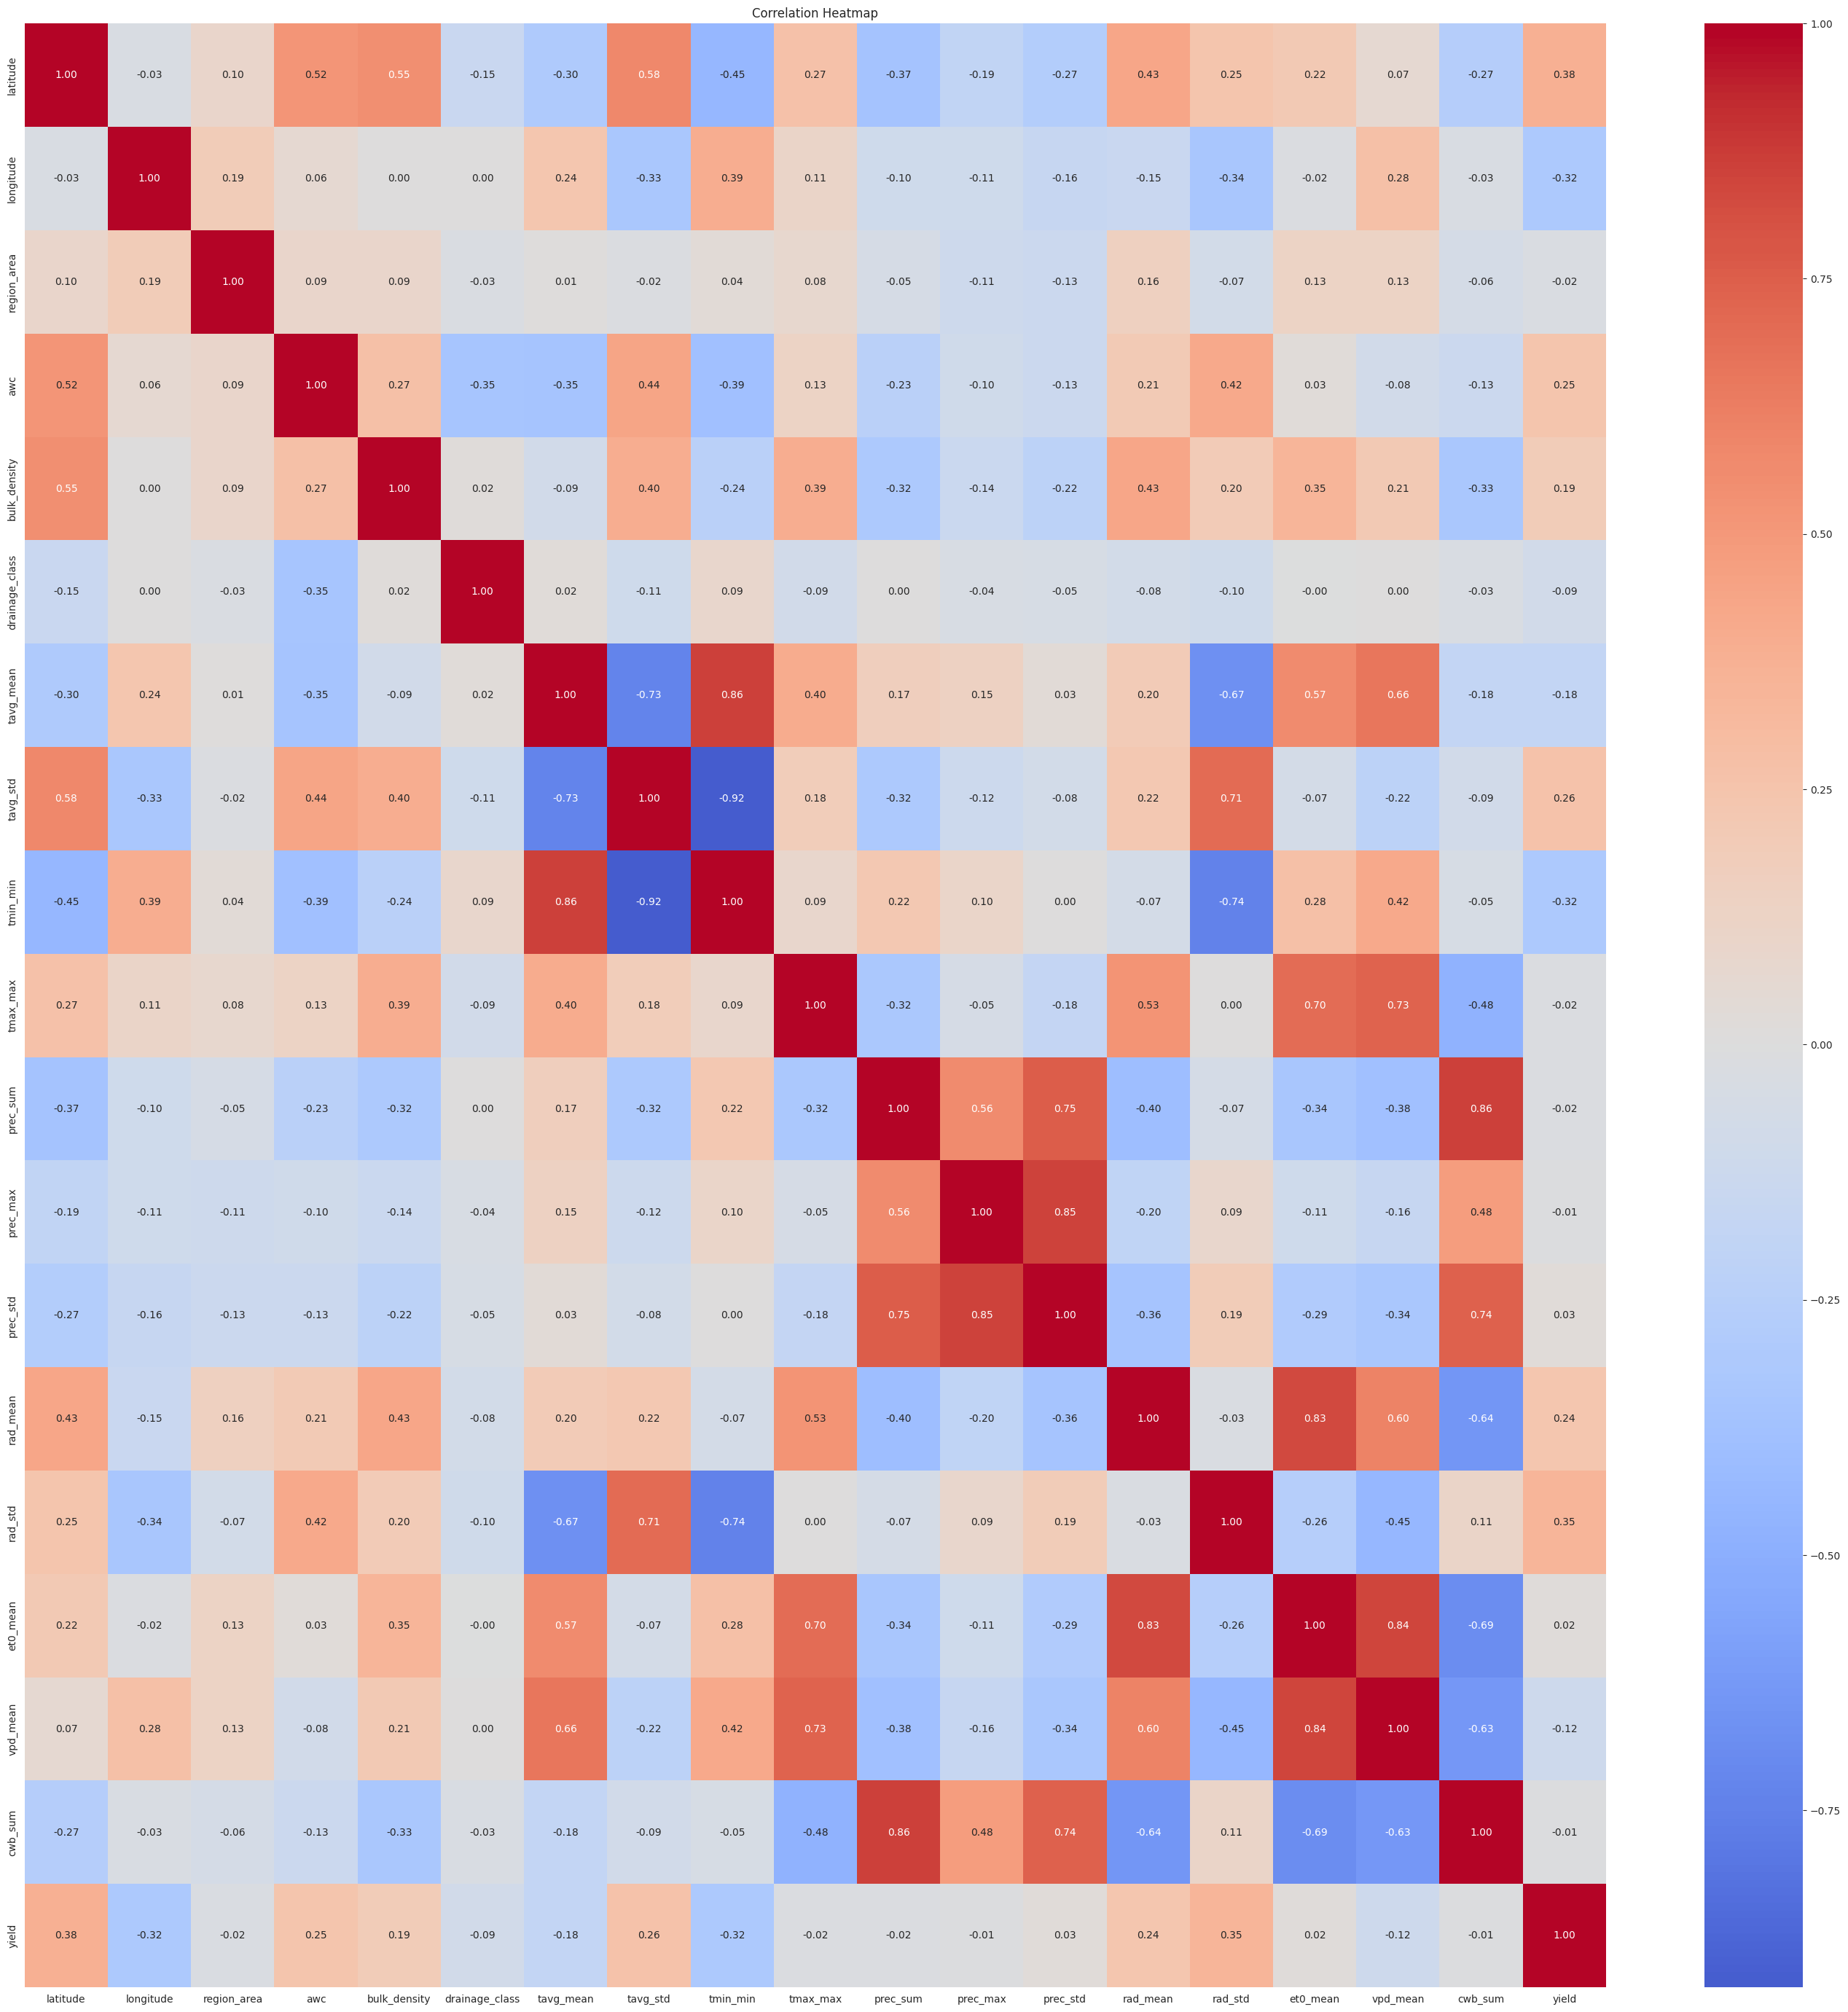

In [9]:
# Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(35,35))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [10]:
# Correlation of each numeric feature with the target, sorted
if TARGET_COLUMN in numeric_df.columns:
    corr_with_target = numeric_df.corr()[TARGET_COLUMN].sort_values(ascending=False)
    print("Correlation with target:\n")
    print(corr_with_target)

Correlation with target:

yield             1.000000
latitude          0.380862
rad_std           0.349109
tavg_std          0.256355
awc               0.245766
rad_mean          0.235764
bulk_density      0.189701
prec_std          0.026531
et0_mean          0.020165
prec_max         -0.011369
cwb_sum          -0.014177
tmax_max         -0.017662
prec_sum         -0.020775
region_area      -0.024815
drainage_class   -0.089747
vpd_mean         -0.118607
tavg_mean        -0.181352
tmin_min         -0.319797
longitude        -0.320859
Name: yield, dtype: float64


In [11]:
# Drop exact duplicate rows
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - df.shape[0]} duplicate rows.")

# Handle missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            fill_value = df[col].mode()[0]
        else:
            fill_value = df[col].median()
        df[col] = df[col].fillna(fill_value)
        print(f"Filled missing values in '{col}' with {fill_value}")

print("\nRemaining missing values:", df.isnull().sum().sum())

Dropped 0 duplicate rows.

Remaining missing values: 0


In [12]:
# Encode categorical columns (label encoding)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if TARGET_COLUMN in categorical_cols:
    categorical_cols.remove(TARGET_COLUMN)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded categorical column: '{col}' -> classes: {list(le.classes_)}")

if not categorical_cols:
    print("No categorical columns found — nothing to encode.")

Encoded categorical column: 'crop' -> classes: ['maize', 'wheat', 'winter_wheat']


In [13]:
# Define features (X) and target (y)
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("Feature columns used:", list(X.columns))
print("Target column:", TARGET_COLUMN)

Feature columns used: ['crop', 'latitude', 'longitude', 'region_area', 'awc', 'bulk_density', 'drainage_class', 'tavg_mean', 'tavg_std', 'tmin_min', 'tmax_max', 'prec_sum', 'prec_max', 'prec_std', 'rad_mean', 'rad_std', 'et0_mean', 'vpd_mean', 'cwb_sum']
Target column: yield


In [14]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 172049 rows
Test set size: 43013 rows


# Model Comparison & Hyperparameter Tuning
Three models are trained, tuned and compared: **XGBoost**, **Random Forest** and **Extra Trees**.

Tuning is done with `RandomizedSearchCV` (5-fold CV, scored on R²) using the **training set only**, so the test set stays untouched until the final comparison.

In [15]:
# ---------------- Tuning settings (change these if needed) ----------------
RANDOM_STATE = 42
CV_FOLDS     = 5      # cross-validation folds
N_ITER       = 40     # random combinations tried per model. Raise (e.g. 80-100) for a more thorough search, lower (e.g. 20) if it is too slow

cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Helper: evaluate any fitted model on the test set
def evaluate(model, X_te, y_te):
    pred = model.predict(X_te)
    return {
        'R2'  : r2_score(y_te, pred),
        'MAE' : mean_absolute_error(y_te, pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, pred)),
    }

results = {}          # final numbers for the comparison table
tuned_models = {}     # best fitted estimator per model
print("Settings ready.")

Settings ready.


## 1. Baselines (default-ish settings, before tuning)

In [16]:
baselines = {
    'XGBoost'      : XGBRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist'),
    'Random Forest': RandomForestRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees'  : ExtraTreesRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1),
}

baseline_results = {}
for name, model in baselines.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    baseline_results[name] = evaluate(model, X_test, y_test)
    print(f"{name:14s} | R2: {baseline_results[name]['R2']:.4f} | "
          f"MAE: {baseline_results[name]['MAE']:.4f} | RMSE: {baseline_results[name]['RMSE']:.4f} "
          f"| {time.time()-t0:.1f}s")

baseline_df = pd.DataFrame(baseline_results).T
baseline_df

XGBoost        | R2: 0.8838 | MAE: 0.7395 | RMSE: 1.0403 | 2.2s
Random Forest  | R2: 0.9028 | MAE: 0.6564 | RMSE: 0.9517 | 523.4s
Extra Trees    | R2: 0.9068 | MAE: 0.6407 | RMSE: 0.9316 | 99.1s


,R2,MAE,RMSE
XGBoost,0.883799,0.739516,1.040326
Random Forest,0.902761,0.656411,0.951664
Extra Trees,0.906820,0.640657,0.931593


## 2. Tune XGBoost

In [ ]:
# xgb_param_dist = {
#     'n_estimators'    : randint(200, 1200),
#     'learning_rate'   : loguniform(0.01, 0.3),
#     'max_depth'       : randint(3, 12),
#     'min_child_weight': randint(1, 10),
#     'subsample'       : uniform(0.6, 0.4),        # 0.6 - 1.0
#     'colsample_bytree': uniform(0.5, 0.5),        # 0.5 - 1.0
#     'gamma'           : uniform(0, 0.5),
#     'reg_alpha'       : loguniform(1e-3, 10),
#     'reg_lambda'      : loguniform(1e-2, 10),
# }

# xgb_search = RandomizedSearchCV(
#     estimator=XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, tree_method='hist'),
#     param_distributions=xgb_param_dist,
#     n_iter=N_ITER,
#     cv=cv,
#     scoring='r2',
#     n_jobs=-1,
#     random_state=RANDOM_STATE,
#     verbose=1,
#     refit=True,
# )

# t0 = time.time()
# xgb_search.fit(X_train, y_train)
# xgb_time = time.time() - t0

# print(f"\nXGBoost tuning finished in {xgb_time/60:.1f} min")
# print("Best parameters:")
# for k, v in xgb_search.best_params_.items():
#     print(f"  {k}: {v}")
# print(f"Best CV R2: {xgb_search.best_score_:.4f}")

# tuned_models['XGBoost'] = xgb_search.best_estimator_
# results['XGBoost'] = {'CV R2': xgb_search.best_score_, **evaluate(xgb_search.best_estimator_, X_test, y_test)}
# print(f"Test R2   : {results['XGBoost']['R2']:.4f}")

## 3. Tune Random Forest

In [ ]:
# rf_param_dist = {
#     'n_estimators'    : randint(100, 800),
#     'max_depth'       : [None, 10, 20, 30, 40, 50],
#     'min_samples_split': randint(2, 20),
#     'min_samples_leaf' : randint(1, 10),
#     'max_features'    : ['sqrt', 'log2', 0.5, 0.7, 1.0],
#     'bootstrap'       : [True, False],
# }

# rf_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
#     param_distributions=rf_param_dist,
#     n_iter=N_ITER,
#     cv=cv,
#     scoring='r2',
#     n_jobs=-1,
#     random_state=RANDOM_STATE,
#     verbose=1,
#     refit=True,
# )

# t0 = time.time()
# rf_search.fit(X_train, y_train)
# rf_time = time.time() - t0

# print(f"\nRandom Forest tuning finished in {rf_time/60:.1f} min")
# print("Best parameters:")
# for k, v in rf_search.best_params_.items():
#     print(f"  {k}: {v}")
# print(f"Best CV R2: {rf_search.best_score_:.4f}")

# tuned_models['Random Forest'] = rf_search.best_estimator_
# results['Random Forest'] = {'CV R2': rf_search.best_score_, **evaluate(rf_search.best_estimator_, X_test, y_test)}
# print(f"Test R2   : {results['Random Forest']['R2']:.4f}")

## 4. Tune Extra Trees

In [ ]:
# et_param_dist = {
#     'n_estimators'    : randint(100, 800),
#     'max_depth'       : [None, 10, 20, 30, 40, 50],
#     'min_samples_split': randint(2, 20),
#     'min_samples_leaf' : randint(1, 10),
#     'max_features'    : ['sqrt', 'log2', 0.5, 0.7, 1.0],
#     'bootstrap'       : [True, False],
# }

# et_search = RandomizedSearchCV(
#     estimator=ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=1),
#     param_distributions=et_param_dist,
#     n_iter=N_ITER,
#     cv=cv,
#     scoring='r2',
#     n_jobs=-1,
#     random_state=RANDOM_STATE,
#     verbose=1,
#     refit=True,
# )

# t0 = time.time()
# et_search.fit(X_train, y_train)
# et_time = time.time() - t0

# print(f"\nExtra Trees tuning finished in {et_time/60:.1f} min")
# print("Best parameters:")
# for k, v in et_search.best_params_.items():
#     print(f"  {k}: {v}")
# print(f"Best CV R2: {et_search.best_score_:.4f}")

# tuned_models['Extra Trees'] = et_search.best_estimator_
# results['Extra Trees'] = {'CV R2': et_search.best_score_, **evaluate(et_search.best_estimator_, X_test, y_test)}
# print(f"Test R2   : {results['Extra Trees']['R2']:.4f}")

## 5. Compare all three models
The best model is chosen by **cross-validated R² on the training data** (not by the test score), which keeps the test set an honest, unbiased final check.

In [ ]:
# comparison = pd.DataFrame(results).T[['CV R2', 'R2', 'MAE', 'RMSE']]
# comparison.columns = ['CV R2 (train)', 'Test R2', 'Test MAE', 'Test RMSE']
# comparison['Baseline Test R2'] = pd.Series({k: v['R2'] for k, v in baseline_results.items()})
# comparison['R2 gain from tuning'] = comparison['Test R2'] - comparison['Baseline Test R2']
# comparison = comparison.sort_values('CV R2 (train)', ascending=False)

# display(comparison.round(4))

# best_name  = comparison.index[0]
# best_model = tuned_models[best_name]
# print(f"\nBest model (by CV R2): {best_name}")
# print(f"Test R2 = {comparison.loc[best_name, 'Test R2']:.4f} | "
#       f"MAE = {comparison.loc[best_name, 'Test MAE']:.4f} | "
#       f"RMSE = {comparison.loc[best_name, 'Test RMSE']:.4f}")

# # Visual comparison
# fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
# for ax, col, color in zip(axes, ['Test R2', 'Test MAE', 'Test RMSE'], ['seagreen', 'steelblue', 'indianred']):
#     vals = comparison[col]
#     ax.bar(vals.index, vals.values, color=color, edgecolor='k')
#     ax.set_title(col)
#     ax.tick_params(axis='x', rotation=15)
#     for i, v in enumerate(vals.values):
#         ax.text(i, v, f"{v:.3f}", ha='center', va='bottom', fontsize=9)
# plt.tight_layout()
# plt.show()

## 6. Best model — detailed evaluation
The charts below automatically use whichever model won the comparison above.

In [ ]:
# y_pred = best_model.predict(X_test)

# r2   = r2_score(y_test, y_pred)
# mae  = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# print(f"Tuned {best_name} — Test Set Performance:")
# print(f"  R² Score : {r2:.4f}")
# print(f"  MAE      : {mae:.4f}")
# print(f"  RMSE     : {rmse:.4f}")

# # Extra check: 5-fold CV on the FULL dataset for the winning configuration
# full_cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='r2', n_jobs=-1)
# print(f"\n5-Fold CV R² on full data: {np.round(full_cv_scores, 4)}")
# print(f"Mean CV R²: {full_cv_scores.mean():.4f}  (+/- {full_cv_scores.std():.4f})")

In [ ]:
# importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# plt.figure(figsize=(8,5))
# sns.barplot(x=importances.values, y=importances.index, palette='viridis')
# plt.title(f'Feature Importance ({best_name})')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.show()

# print(importances)

In [ ]:
# plt.figure(figsize=(7,7))
# plt.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolor='k')
# min_val = min(y_test.min(), y_pred.min())
# max_val = max(y_test.max(), y_pred.max())
# plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
# plt.xlabel('Actual Yield')
# plt.ylabel('Predicted Yield')
# plt.title(f'Predicted vs. Actual Yield ({best_name})')
# plt.legend()
# plt.show()

In [ ]:
# residuals = y_test - y_pred

# fig, axes = plt.subplots(1, 2, figsize=(14,5))

# axes[0].scatter(y_pred, residuals, alpha=0.6, color='indianred', edgecolor='k')
# axes[0].axhline(0, color='black', linestyle='--')
# axes[0].set_xlabel('Predicted Yield')
# axes[0].set_ylabel('Residual (Actual - Predicted)')
# axes[0].set_title('Residuals vs. Predicted')

# sns.histplot(residuals, kde=True, ax=axes[1], color='indianred')
# axes[1].set_title('Distribution of Residuals')
# axes[1].set_xlabel('Residual')

# plt.tight_layout()
# plt.show()

## 7. Save the best model

In [ ]:
# from google.colab import files

# model_bundle = {
#     'model': best_model,
#     'model_name': best_name,
#     'best_params': best_model.get_params(),
#     'feature_columns': list(X.columns),
#     'target_column': TARGET_COLUMN,
#     'label_encoders': label_encoders,
# }

# joblib.dump(model_bundle, 'CYP.pkl')
# print(f"Saved tuned {best_name} as 'CYP.pkl'")

# files.download('CYP.pkl')

In [ ]:
# Example: load the saved model and predict on new data
# (edit the columns below so they match your feature columns)

# bundle = joblib.load("CYP.pkl")

# loaded_model = bundle["model"]
# feature_cols = bundle["feature_columns"]
# encoders     = bundle["label_encoders"]

# new_data = pd.DataFrame({
#     "N": [50, 75, 100],
#     "P": [15, 25, 35],
#     "K": [50, 100, 150],
#     "temp": [20, 25, 30]
# })

# new_data = new_data[feature_cols]
# prediction = loaded_model.predict(new_data)
# print("Predicted yields:", prediction)